In [57]:
import numpy as np
import globals as gl
import nibabel as nb
import os
import matplotlib.pyplot as plt
import pandas as pd
from nitools import spm
import nitools as nt
import warnings
from util import load_matlab_hrf

warnings.filterwarnings("ignore")
plt.style.use('default')


In [58]:
glm = 12
sn = 107
path_glm = os.path.join(gl.baseDir, 'smp2',  f'{gl.glmDir}{glm}', f'subj{sn}')
SPM = nt.spm.SpmGlm(path_glm)
SPM.get_info_from_spm_mat()

In [59]:
roi = os.path.join(gl.baseDir, 'smp2',  'ROI', f'subj{sn}', 'ROI.L.M1.nii')
roi_img = nb.load(roi)
coords = nt.get_mask_coords(roi_img)
y_raw = nt.sample_images(SPM.rawdata_files, coords)

In [66]:
y_scl = y_raw * SPM.gSF[:, None]
P = [ 8., 14.,  1.,  1. , 6. , 0., 32.]
bf, _ = nt.spm.spm_hrf(1, P)
SPM.convolve_glm(bf)
_, info, y_filt, y_hat, y_adj, residuals = SPM.rerun_glm(y_scl)
dof = residuals.shape[0] - np.linalg.matrix_rank(SPM.X)
rss = np.nansum(residuals * residuals, axis=0)  # voxelwise RSS
resms = rss / dof
print(np.nanmean(resms))

143.95730001763772


In [67]:
dat = pd.read_csv(os.path.join(gl.baseDir, 'smp2',  'behavioural', f'subj{sn}', f'smp2_{sn}.dat'), sep='\t')
BN_mapping = {BN: i+1 for i, BN in enumerate(dat['BN'].unique())}
at = dat.startTRReal + (dat.BN.map(BN_mapping) - 1) * 336;
at_go = at[dat['GoNogo']=='go']
at_nogo = at[dat['GoNogo']=='nogo']
y_cut_adj_go = spm.cut(y_adj, 10, at_go, 20).mean(axis=(0, 2))
y_cut_hat_go = spm.cut(y_hat, 10, at_go, 20).mean(axis=(0, 2))
y_cut_adj_nogo = spm.cut(y_adj, 10, at_nogo, 20).mean(axis=(0, 2))
y_cut_hat_nogo = spm.cut(y_hat, 10, at_nogo, 20).mean(axis=(0, 2))

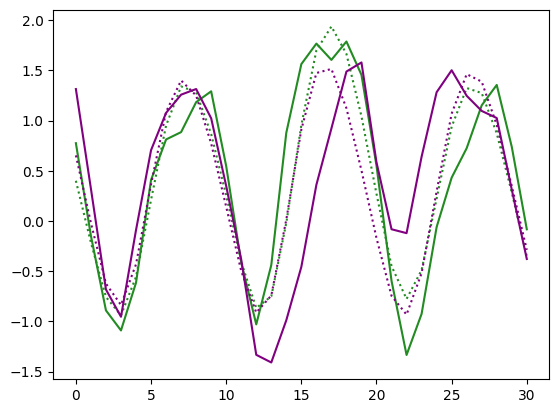

In [68]:
plt.plot(y_cut_adj_go, color='forestgreen')
plt.plot(y_cut_hat_go, color='forestgreen', ls=':')
plt.plot(y_cut_adj_nogo, color='purple')
plt.plot(y_cut_hat_nogo, color='purple', ls=':')